Original shape: (42016, 52)
Reduced shape after PCA: (42016, 14)


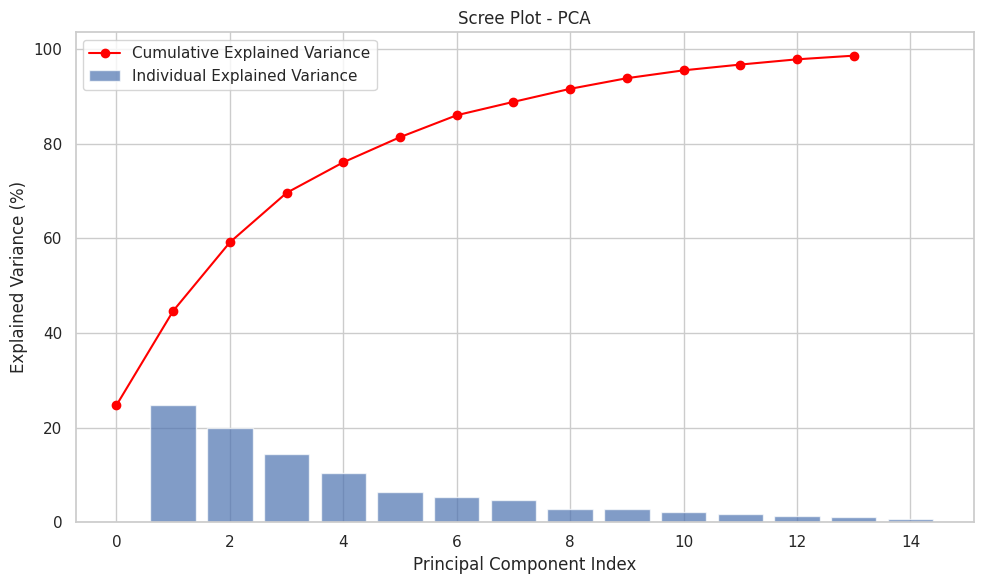

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
data = pd.read_csv("/content/DMC2_S_CP2_52.csv")

# 2. Extract the target column before dropping it
y = data['CURRENT|6']

X = data.iloc[:, :-4]

# 3. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA (retain 95% variance)
pca = PCA(n_components=0.98)
X_pca = pca.fit_transform(X_scaled)

# 5. Display shapes
print(f"Original shape: {X.shape}")
print(f"Reduced shape after PCA: {X_pca.shape}")

# 6. Create DataFrame with principal components
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
pca_df['CURRENT|6'] = y.values  # Add target column back

# 7. Save reduced dataset
pca_df.to_csv("pca_data.csv", index=False)

# 8. Plot Scree Plot (individual + cumulative variance)
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Bar plot for individual variance
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_*100, alpha=0.7, label='Individual Explained Variance')

# Line plot for cumulative variance
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100,
         color='red', marker='o', label='Cumulative Explained Variance')

plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot - PCA")
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,CURRENT|6
0,9.280211,-1.423706,1.970918,2.432996,-0.332150,-1.194646,0.705661,-0.719141,-0.189582,0.054184,0.235312,-0.247417,0.223657,0.020167,0.0
1,9.280008,-1.424751,1.969029,2.433316,-0.331677,-1.194442,0.705670,-0.723126,-0.190830,0.058199,0.235567,-0.246134,0.224481,0.020845,0.0
2,9.279963,-1.425712,1.969636,2.433056,-0.331909,-1.193693,0.706448,-0.724401,-0.190480,0.058455,0.235828,-0.245973,0.224422,0.021009,0.0
3,9.280345,-1.424548,1.969022,2.432979,-0.331946,-1.193731,0.706796,-0.720871,-0.190329,0.057981,0.235773,-0.245490,0.222659,0.020768,0.0
4,9.280459,-1.424924,1.968945,2.430834,-0.331751,-1.194695,0.705038,-0.718663,-0.193937,0.057010,0.237353,-0.248590,0.224337,0.017982,0.0


## LOADING PLOT

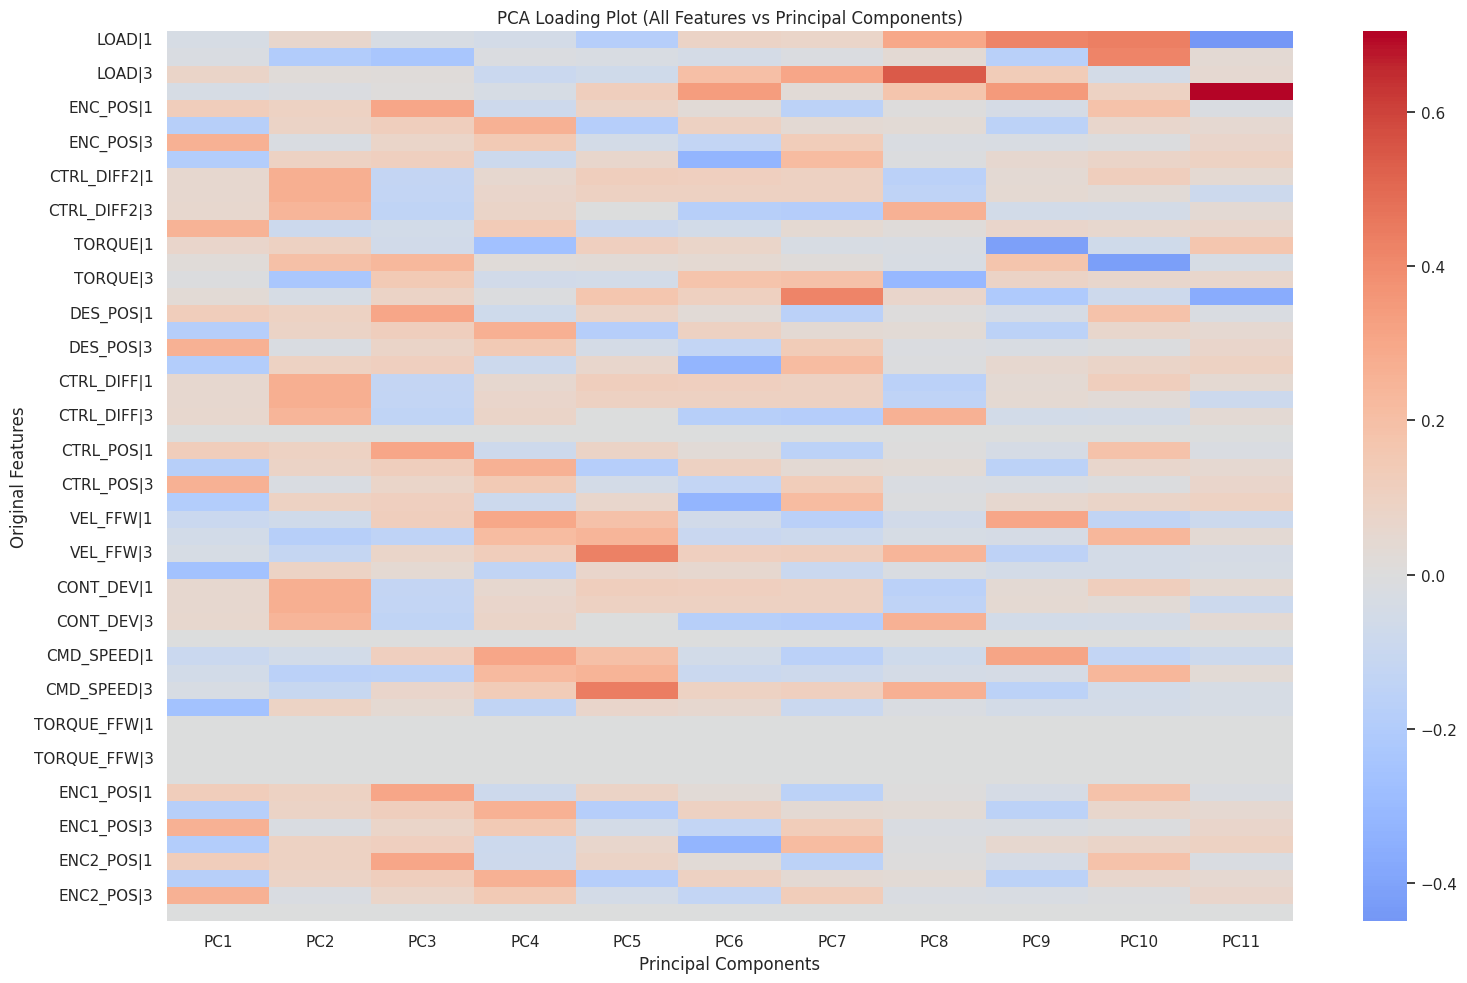

In [ ]:
# Create loading matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

# Plot loading heatmap for all features
plt.figure(figsize=(16, 10))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("PCA Loading Plot (All Features vs Principal Components)")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.tight_layout()
plt.show()

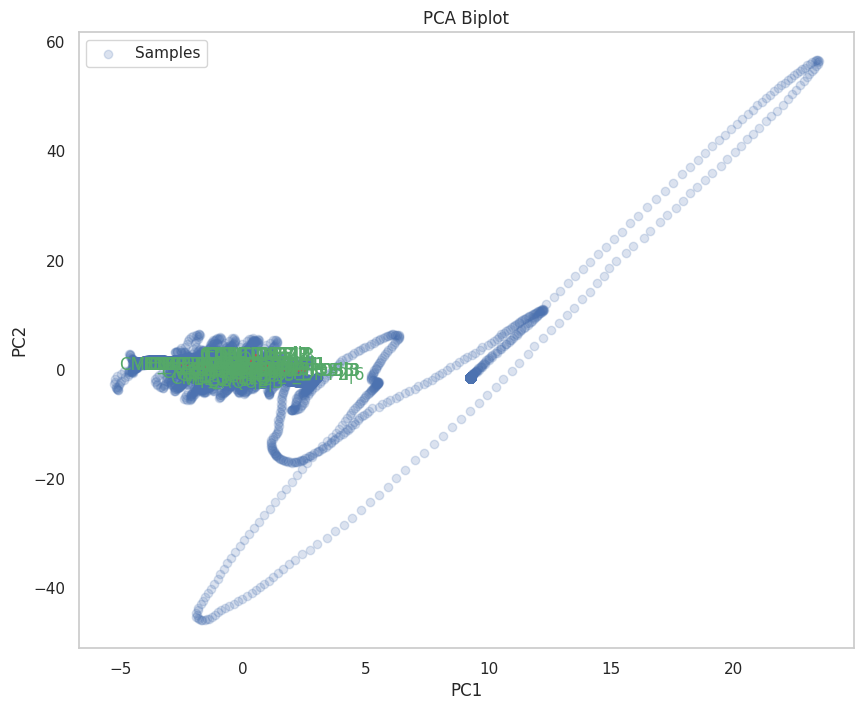

In [ ]:
import matplotlib.pyplot as plt

# Loadings
loadings = pca.components_.T
feature_names = data.columns[:52]

plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.2, label='Samples')
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[i, 0]*10, loadings[i, 1]*10, color='r', alpha=0.5)
    plt.text(loadings[i, 0]*10.2, loadings[i, 1]*10.2, feature, color='g', ha='center', va='center')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.grid()
plt.legend()
plt.show()

/tmp/ipython-input-12-3193216441.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loading_df.PC1[i],
/tmp/ipython-input-12-3193216441.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loading_df.PC2[i],
/tmp/ipython-input-12-3193216441.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(loading_df.PC1[i]*1.1,
/tmp/ipython-input-12-3193216441.py:20: FutureWarning: Series.__getitem__ treating keys as positions is depr

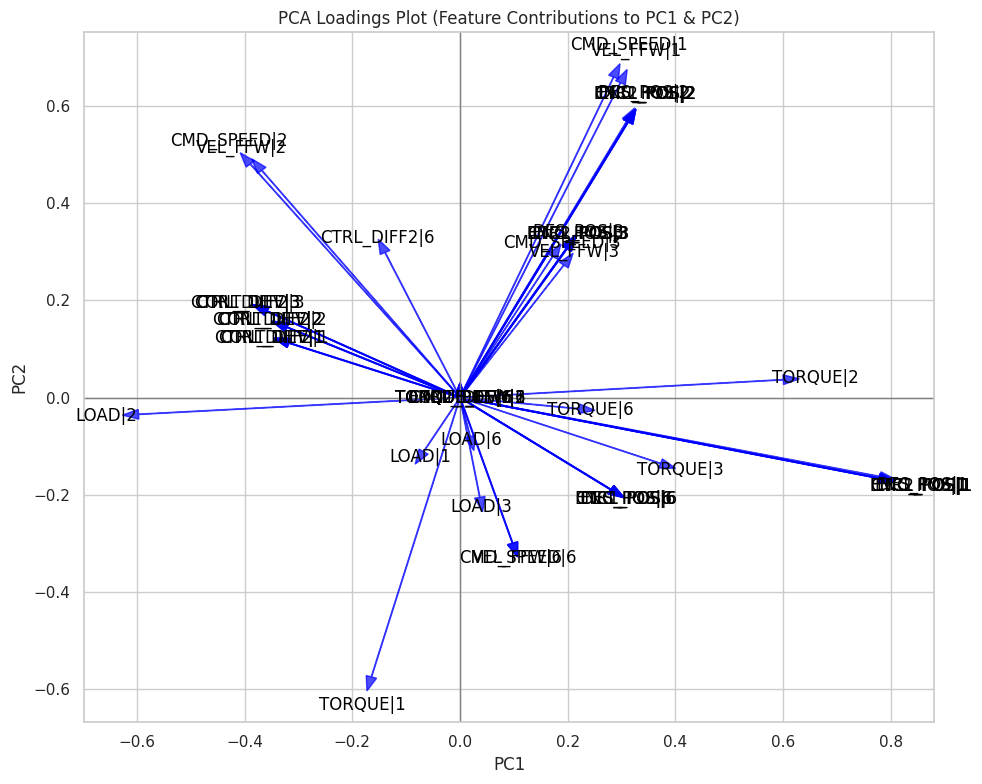

In [ ]:
# 9. Loadings Plot - shows how features contribute to PCs
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create a DataFrame for loadings
loading_df = pd.DataFrame(loadings[:, 2:4],  # Just PC1 and PC2 for 2D plot
                          columns=['PC1', 'PC2'],
                          index=X.columns)

# Plot the loadings
plt.figure(figsize=(10, 8))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

for i in range(len(loading_df)):
    plt.arrow(0, 0,
              loading_df.PC1[i],
              loading_df.PC2[i],
              color='blue', alpha=0.7, head_width=0.02)
    plt.text(loading_df.PC1[i]*1.1,
             loading_df.PC2[i]*1.1,
             loading_df.index[i],
             color='black', ha='center', va='center')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Loadings Plot (Feature Contributions to PC1 & PC2)")
plt.grid(True)
plt.tight_layout()
plt.show()

### New CODE - LOADING

/tmp/ipython-input-11-94272363.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_features.PC1[i]/scale,
/tmp/ipython-input-11-94272363.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_features.PC2[i]/scale,
/tmp/ipython-input-11-94272363.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(top_features.PC1[i]/scale * 1.7,
/tmp/ipython-input-11-94272363.py:27: FutureWarning: Series.__getitem__ treating keys as

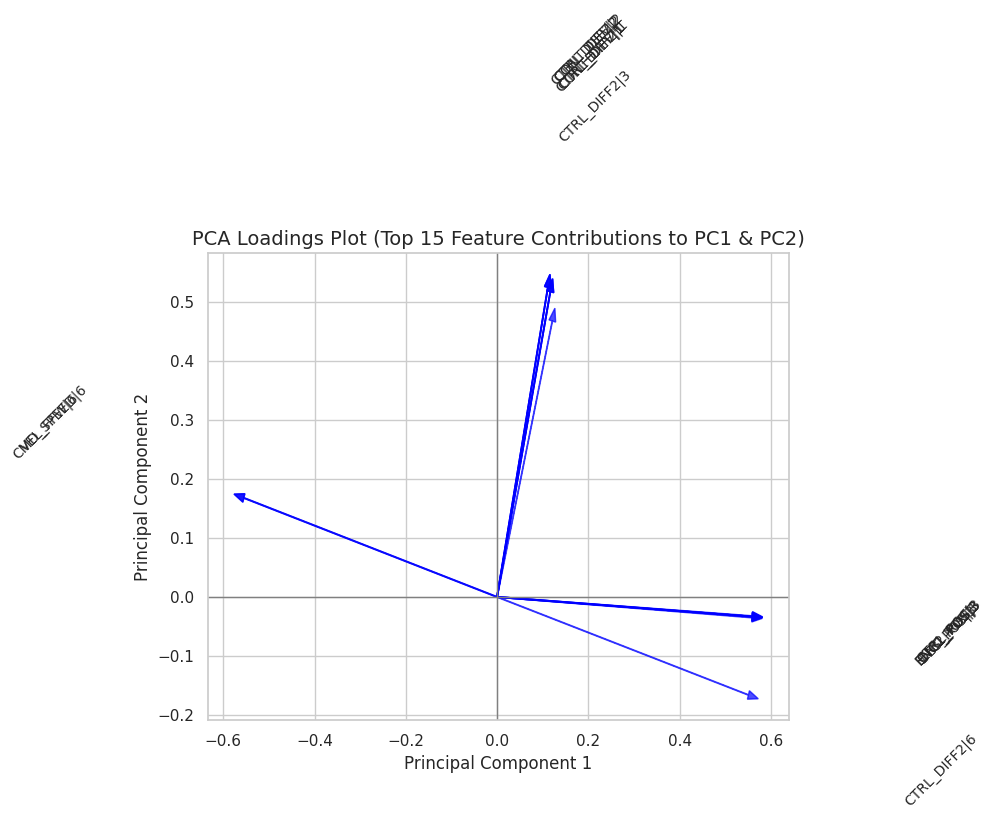

In [ ]:
# Loadings: how each feature contributes to PCs
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create a DataFrame for PC1 & PC2 loadings
loading_df = pd.DataFrame(loadings[:, :2], columns=['PC1', 'PC2'], index=X.columns)

# OPTIONAL: Add magnitude to filter top features
loading_df['magnitude'] = np.sqrt(loading_df.PC1**2 + loading_df.PC2**2)

# Keep only top 15 contributing features for clarity
top_features = loading_df.nlargest(15, 'magnitude')

# === Loadings Plot ===
plt.figure(figsize=(12, 10))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

scale = 1.5  # Adjust arrow length and text spacing

for i in range(len(top_features)):
    plt.arrow(0, 0,
              top_features.PC1[i]/scale,
              top_features.PC2[i]/scale,
              color='blue', alpha=0.7, head_width=0.015, length_includes_head=True)

    plt.text(top_features.PC1[i]/scale * 1.7,
             top_features.PC2[i]/scale * 1.7,
             top_features.index[i],
             fontsize=10, ha='center', va='center', rotation=45)

plt.title("PCA Loadings Plot (Top 15 Feature Contributions to PC1 & PC2)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## PC1 new Loading Plot - least contrib. feats

> Add blockquote



LOAD|6          3.560016e-02
VEL_FFW|3       3.195334e-02
TORQUE|6        3.190627e-02
LOAD|1          3.078195e-02
CMD_SPEED|3     2.867711e-02
LOAD|2          1.900359e-02
TORQUE|2        1.842266e-02
TORQUE|3        1.068013e-02
CTRL_DIFF|6     3.587324e-43
CONT_DEV|6      0.000000e+00
TORQUE_FFW|1    0.000000e+00
TORQUE_FFW|6    0.000000e+00
TORQUE_FFW|3    0.000000e+00
TORQUE_FFW|2    0.000000e+00
ENC2_POS|6      0.000000e+00
dtype: float64


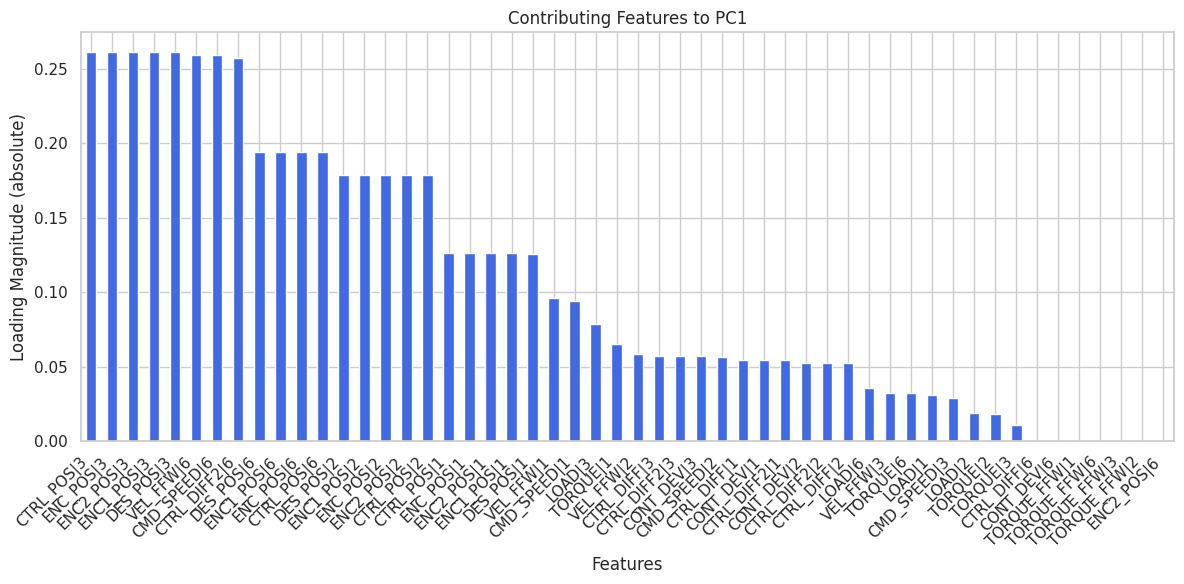

In [ ]:
# Extract loading scores for PC1
pc1_loadings = pca.components_[0]  # PC1 is the first component
loading_scores_df = pd.Series(pc1_loadings, index=X.columns)

# Take absolute values for strength, then get top 20
top_20_features = loading_scores_df.abs().sort_values(ascending=False).head(52)
print(loading_scores_df.abs().sort_values(ascending=False).tail(15))

# Plot bar chart
plt.figure(figsize=(12, 6))
top_20_features.plot(kind='bar', color='royalblue')
plt.title("Contributing Features to PC1")
plt.ylabel("Loading Magnitude (absolute)")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

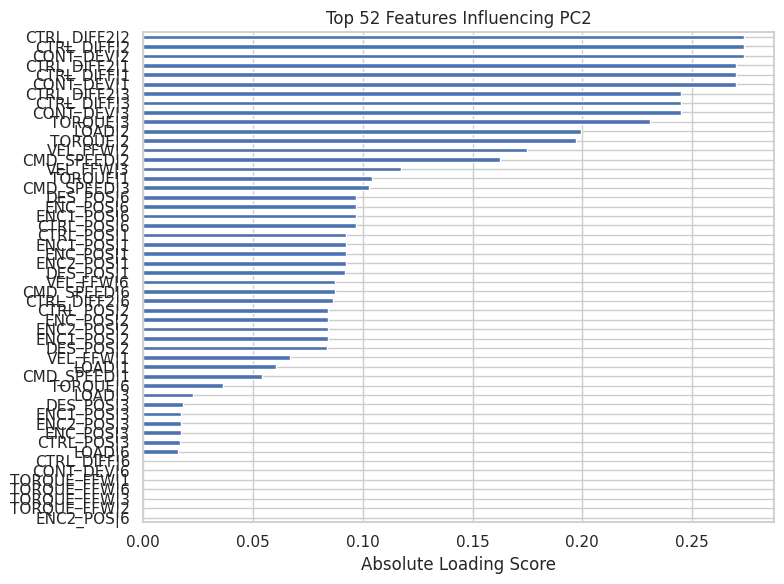

In [ ]:
import numpy as np

# Top features for PC1
pc_index = 1  # 0 for PC1, 1 for PC2, etc.
top_n = 52
loading_scores = pd.Series(np.abs(loadings[:, pc_index]), index=feature_names)
top_features = loading_scores.nlargest(top_n)

top_features.plot(kind='barh', figsize=(8, 6), title=f"Top {top_n} Features Influencing PC{pc_index + 1}")
plt.xlabel("Absolute Loading Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## PC2 least contrib. feats

CTRL_DIFF2|2    0.273613
CTRL_DIFF|2     0.273613
CONT_DEV|2      0.273613
CTRL_DIFF2|1    0.269919
CTRL_DIFF|1     0.269919
CONT_DEV|1      0.269919
CTRL_DIFF2|3    0.244945
CTRL_DIFF|3     0.244945
CONT_DEV|3      0.244945
TORQUE|3        0.230947
dtype: float64
ENC_POS|3       1.732257e-02
CTRL_POS|3      1.682273e-02
LOAD|6          1.581547e-02
CTRL_DIFF|6     5.739719e-42
CONT_DEV|6      0.000000e+00
TORQUE_FFW|1    0.000000e+00
TORQUE_FFW|6    0.000000e+00
TORQUE_FFW|3    0.000000e+00
TORQUE_FFW|2    0.000000e+00
ENC2_POS|6      0.000000e+00
dtype: float64


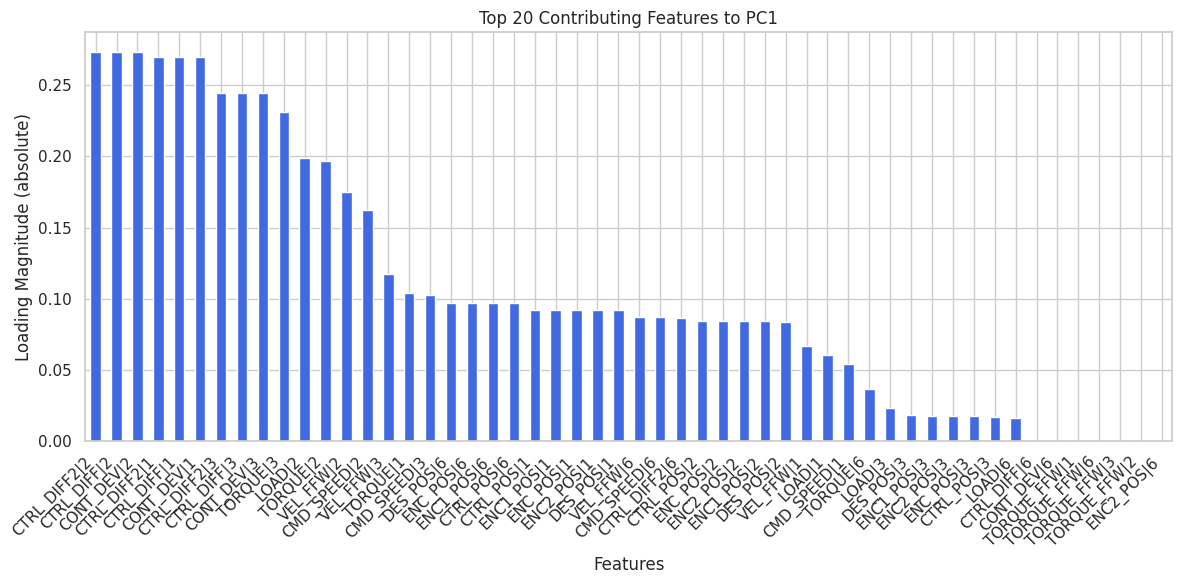

In [ ]:
# Extract loading scores for PC1
pc1_loadings = pca.components_[1]  # PC1 is the first component
loading_scores_df = pd.Series(pc1_loadings, index=X.columns)

# Take absolute values for strength, then get top 20
top_20_features = loading_scores_df.abs().sort_values(ascending=False).head(52)

print(loading_scores_df.abs().sort_values(ascending=False).head(10))

print(loading_scores_df.abs().sort_values(ascending=False).tail(10))

# Plot bar chart
plt.figure(figsize=(12, 6))
top_20_features.plot(kind='bar', color='royalblue')
plt.title("Top 20 Contributing Features to PC1")
plt.ylabel("Loading Magnitude (absolute)")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

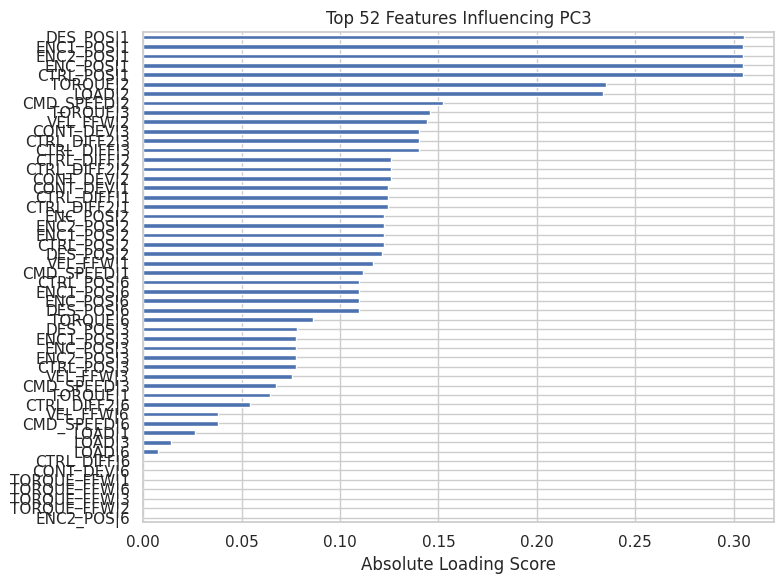

In [ ]:
import numpy as np

# Top features for PC1
pc_index = 2  # 0 for PC1, 1 for PC2, etc.
top_n = 52
loading_scores = pd.Series(np.abs(loadings[:, pc_index]), index=feature_names)
top_features = loading_scores.nlargest(top_n)

top_features.plot(kind='barh', figsize=(8, 6), title=f"Top {top_n} Features Influencing PC{pc_index + 1}")
plt.xlabel("Absolute Loading Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
#Load and Preprocess

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load dataset
#file_list = "/content/DMC2_S_CP2_52.csv"

df = pd.read_csv("/content/DMC2_S_CP2_52.csv")


# Identify features and targets
targets = ['CURRENT|1', 'CURRENT|2', 'CURRENT|3', 'CURRENT|6']
features = [c for c in df.columns if c not in targets]

X = df[features]
y = df[targets]

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

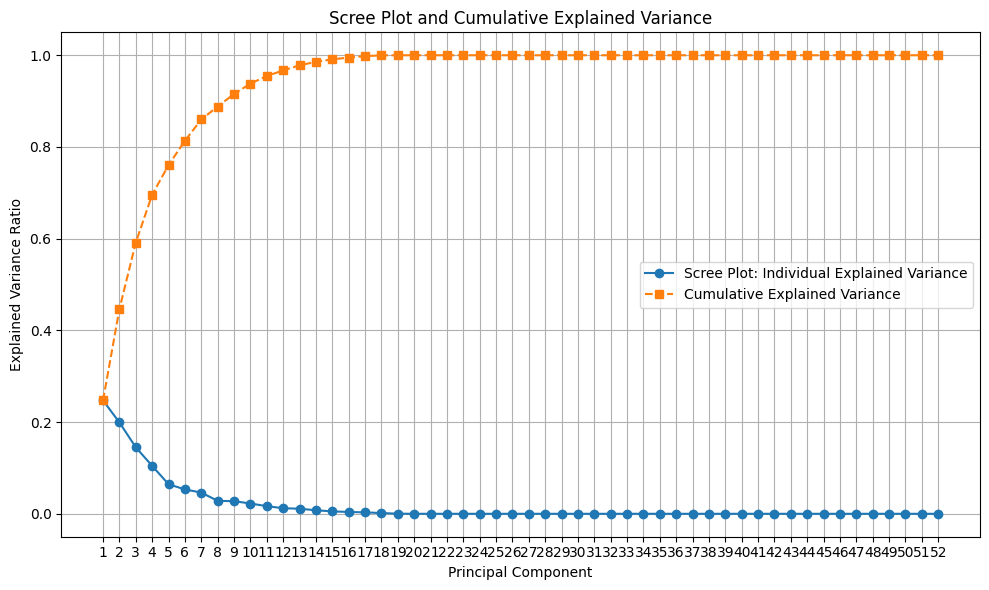

In [ ]:
#Scree plot + Cummulative Variance

# Assuming X_scaled is your standardized feature matrix
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
components = np.arange(1, len(explained_var) + 1)

# Plot Scree Plot and Cumulative Variance
plt.figure(figsize=(10, 6))
plt.plot(components, explained_var, marker='o', label='Scree Plot: Individual Explained Variance')
plt.plot(components, cumulative_var, marker='s', linestyle='--', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot and Cumulative Explained Variance')
plt.xticks(components)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Reduced to 14 components


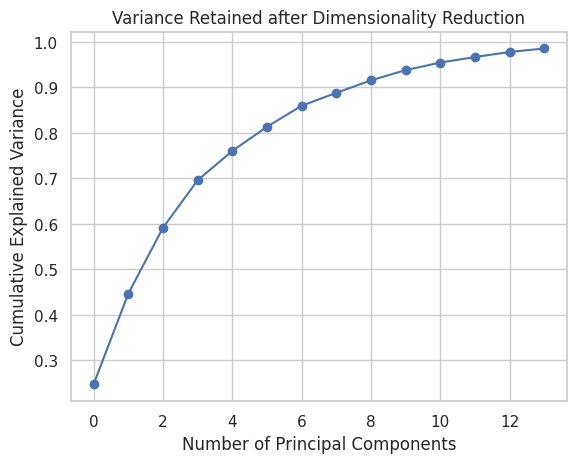

In [ ]:
pca = PCA(n_components=0.98)
X_reduced = pca.fit_transform(X_scaled)
print("Reduced to", X_reduced.shape[1], "components")

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Variance Retained after Dimensionality Reduction')
plt.grid(True)
plt.show()

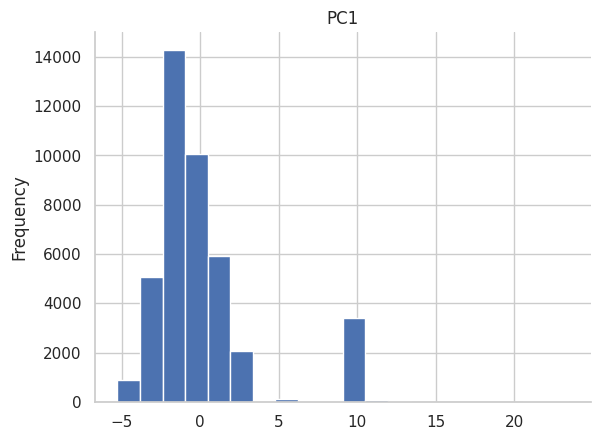

In [ ]:
# @title PC1

from matplotlib import pyplot as plt
pca_df['PC1'].plot(kind='hist', bins=20, title='PC1')
plt.gca().spines[['top', 'right',]].set_visible(False)

Dataset info

In [ ]:
data = pd.read_csv("/content/DMC2_S_CP2_52.csv")

data.info()

pca_df = pd.read_csv("pca_data.csv")
pca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42016 entries, 0 to 42015
Data columns (total 56 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LOAD|1        42016 non-null  float64
 1   LOAD|2        42016 non-null  float64
 2   LOAD|3        42016 non-null  float64
 3   LOAD|6        42016 non-null  float64
 4   ENC_POS|1     42016 non-null  float64
 5   ENC_POS|2     42016 non-null  float64
 6   ENC_POS|3     42016 non-null  float64
 7   ENC_POS|6     42016 non-null  float64
 8   CTRL_DIFF2|1  42016 non-null  float64
 9   CTRL_DIFF2|2  42016 non-null  float64
 10  CTRL_DIFF2|3  42016 non-null  float64
 11  CTRL_DIFF2|6  42016 non-null  float64
 12  TORQUE|1      42016 non-null  float64
 13  TORQUE|2      42016 non-null  float64
 14  TORQUE|3      42016 non-null  float64
 15  TORQUE|6      42016 non-null  float64
 16  DES_POS|1     42016 non-null  float64
 17  DES_POS|2     42016 non-null  float64
 18  DES_POS|3     42016 non-nu

## Predict target in PCA Dataset using LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# --- 1. Load PCA-reduced dataset ---
pca_df = pd.read_csv("pca_data.csv")

# --- 2. Split features & target ---
X = pca_df.drop(columns=['CURRENT|6']).values
y = pca_df['CURRENT|6'].values.reshape(-1, 1)

# --- 3. Scale both X and y ---
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

window_size = 30

# --- 4. Create sequences ---
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size)

# --- 5. Train-test split ---
split = int(0.6 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Check shape of training and testing data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (25191, 30, 14)
X_test shape: (16795, 30, 14)
y_train shape: (25191, 1)
y_test shape: (16795, 1)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),   # 11 PCA features
    Dense(32, activation='relu'),
    Dense(1)  # Final output
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# # --- 7. Train the model ---
# history = model.fit(X_train, y_train,
#                     validation_data=(X_test, y_test),
#                     epochs=20, batch_size=64, verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,  # Max possible epochs
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# --- 8. Predict ---
y_pred = model.predict(X_test)

# --- 9. Inverse transform predictions ---
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0200 - val_loss: 5.1819e-04
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 1.8545e-04 - val_loss: 5.2609e-04
Epoch 3/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 8.8747e-05 - val_loss: 4.4565e-04
Epoch 4/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 7.9533e-05 - val_loss: 4.2275e-04
Epoch 5/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 5.7806e-05 - val_loss: 3.8766e-04
Epoch 6/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 5.5274e-05 - val_loss: 4.2385e-04
Epoch 7/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 4.2231e-05 - val_loss: 3.2716e-04
Epoch 8/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 4.8191e-05 - val_loss: 3.2956e-04
Epoch 9/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 3.3969e-05 - val_loss: 3.1397e-04
Epoch 10/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 2.7246e-05 - val_loss: 2.8209e-04
Epoch 11/100
394/394 ━━━━━━━━━━━━━━━━━━━

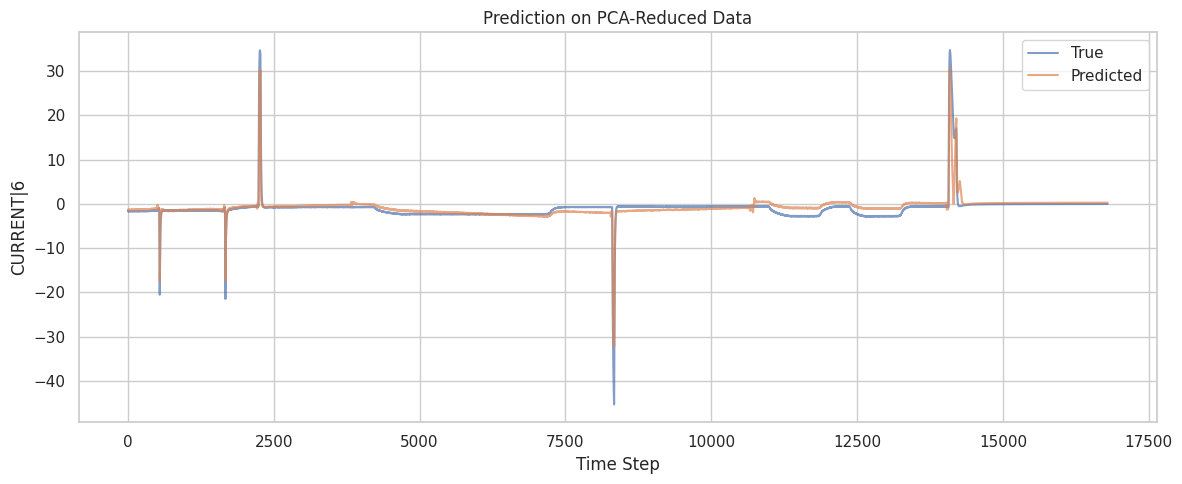

In [ ]:

# --- 11. Plot Predictions vs Actual ---
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='True', alpha=0.7)
plt.plot(y_pred_inv, label='Predicted', alpha=0.7)
plt.title("Prediction on PCA-Reduced Data")
plt.xlabel("Time Step")
plt.ylabel("CURRENT|6")
plt.legend()
plt.tight_layout()
plt.show()

###evaluate

In [ ]:
# --- 10. Evaluation ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


MAE: 0.7468
RMSE: 1.3460
R2 Score: 0.8344


In [ ]:
# New result as a dictionary
new_result = {
    "model": "LSTM-pca",
    "epochs": 20,
    "features": 11,
    "window_size": 10,
    "MAE": 0.1631,
    "RMSE": 0.3023,
    "R2": 0.5648
}

# Convert to DataFrame and concatenate
new_row_df = pd.DataFrame([new_result])
results_df = pd.concat([results_df, new_row_df], ignore_index=True)

In [ ]:
results_df.to_csv("model_results.csv", index=False)

## Predict target in OG Dataset using LSTM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/DMC2_S_CP2_52.csv")  # replace with your filename

# Separate features and target
feature_cols = df.columns[:52]  # First 52 columns are features
target_col = 'CURRENT|6'

X = df[feature_cols]
y = df[[target_col]]

# Normalize
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# Create sequences
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.4, random_state=42)
# Check shape of training and testing data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)




X_train shape: (25191, 30, 52)
X_test shape: (16795, 30, 52)
y_train shape: (25191, 1)
y_test shape: (16795, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 64)             │        29,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,065 (125.25 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0038 - val_loss: 2.1288e-04
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 2.0620e-04 - val_loss: 1.0666e-04
Epoch 3/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 1.2974e-04 - val_loss: 1.1254e-04
Epoch 4/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 9.4755e-05 - val_loss: 7.2313e-05
Epoch 5/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 9.5253e-05 - val_loss: 5.1008e-05
Epoch 6/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 6.0098e-05 - val_loss: 4.4355e-05
Epoch 7/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 5.8368e-05 - val_loss: 9.0243e-05
Epoch 8/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 6.1271e-05 - val_loss: 3.7180e-05
Epoch 9/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 5.8486e-05 - val_loss: 3.6977e-05
Epoch 10/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 3.7138e-05 - val_loss: 3.0317e-05
Epoch 11/100
394/394 ━━━━━━━━━━━━━━━━━━━

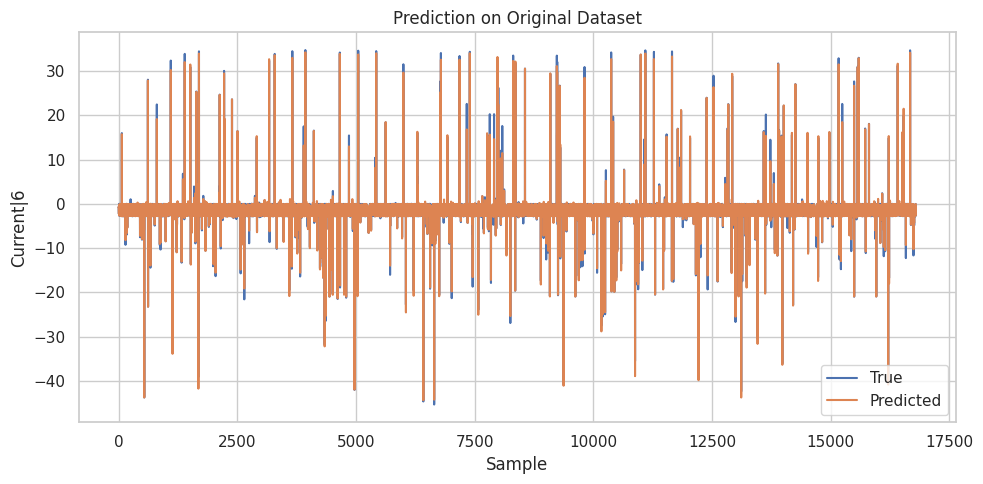

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',      # monitor validation loss
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True,  # go back to best weights
    verbose=1
)

# Train with early stopping
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,           # large number, early stopping will cut it short
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Predict and inverse transform
y_pred = model.predict(X_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='True')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Prediction on Original Dataset')
plt.xlabel('Sample')
plt.ylabel('Current|6')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation

In [ ]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='True')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Prediction on Original Dataset')
plt.xlabel('Sample')
plt.ylabel('Current|6')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming: y_test and y_pred are your true and predicted values
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.0013
RMSE: 0.0022
R2 Score: 0.9959


## SAve REult to new DF

In [ ]:
import pandas as pd

# Try loading existing results if file exists
try:
    results_df = pd.read_csv("model_results.csv")
except FileNotFoundError:
    results_df = pd.DataFrame(columns=["model", "epochs", "features", "window_size", "MAE", "RMSE", "R2"])


In [ ]:


# New result as a dictionary
new_result = {
    "model": "LSTM-Og",
    "epochs": 20,
    "features": 52,
    "window_size": 10,
    "MAE": 0.0063,
    "RMSE": 0.0075,
    "R2": 0.9894
}

# Convert to DataFrame and concatenate
new_row_df = pd.DataFrame([new_result])
results_df = pd.concat([results_df, new_row_df], ignore_index=True)

# Save to CSV
results_df.to_csv("model_results.csv", index=False)

In [ ]:
# Load your dataset
df = pd.read_csv("/content/DMC2_S_CP2_52.csv")  # replace with your filename

# Separate features and target
feature_cols = df.columns[:52]  # First 52 columns are features
target_col = 'CURRENT|6'
y = df[[target_col]]

print(y.mean())
print(y.max())
print(y.min())

CURRENT|6   -1.585481
dtype: float64
CURRENT|6    34.776123
dtype: float64
CURRENT|6   -45.363281
dtype: float64
